In [185]:
import os
import glob as gb
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from pathlib import Path
from PIL import Image
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.10.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Parameters

In [186]:
# ==============================  
# Use the NEW preprocessed FER2013 folders
# ==============================
# These folders should be created by the separate preprocessing notebook.
# Change DATASET_ROOT if your archive folder is somewhere else.

DATASET_ROOT = Path(r"C:\Users\nadee\Downloads\Emotion-Recognition\archive")

train_path = DATASET_ROOT / "train_new"
test_path = DATASET_ROOT / "test_new"

if not train_path.is_dir():
    raise FileNotFoundError(f"Training folder not found: {train_path}\nRun the preprocessing notebook first or fix DATASET_ROOT.")
if not test_path.is_dir():
    raise FileNotFoundError(f"Testing folder not found: {test_path}\nRun the preprocessing notebook first or fix DATASET_ROOT.")

print("Train path:", train_path)
print("Test path:", test_path)
print("Training classes:", sorted(os.listdir(train_path)))
print("Testing classes:", sorted(os.listdir(test_path)))

# FER2013 images are 48x48 grayscale
height = 48
width = 48
color_channels = 1
image_size = (height, width, color_channels)

# FER2013 has 7 emotion classes
num_classes = 6

batch_size = 64
epochs = 50

# The new folders already contain preprocessing and surprise-only augmentation.
# Do not apply preprocessing or ImageDataGenerator again here.
USE_CLASS_WEIGHTS = False
USE_SOFT_CLASS_WEIGHTS = False


Train path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\train_new
Test path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\test_new
Training classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Testing classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [187]:
def load_image_from_new_folder(file_path):
    """
    Load the already-preprocessed image from train_new/test_new.
    No histogram, sharpening, denoising, or augmentation is applied here.
    Only resize safety + grayscale format + scale to 0-1 for model input.
    """
    try:
        image = Image.open(file_path).convert("L")
        image = image.resize((width, height))
        image = np.array(image, dtype="float32") / 255.0
        image = np.expand_dims(image, axis=-1)  # (48, 48) -> (48, 48, 1)
        return image
    except Exception as e:
        print(f"Could not read image: {file_path} | Error: {e}")
        return None


def read_data_from_folder(folder_path, desc="Loading Data"):
    images = []
    labels = []

    class_folders = sorted(os.listdir(folder_path))

    for folder in class_folders:
        class_path = os.path.join(folder_path, folder)

        if not os.path.isdir(class_path):
            continue

        files = []
        for ext in ["*.jpg", "*.jpeg", "*.png"]:
            files.extend(gb.glob(os.path.join(class_path, ext)))

        for file in tqdm(files, desc=f"{desc} - {folder}"):
            image = load_image_from_new_folder(file)

            if image is not None:
                images.append(image)
                labels.append(folder)

    return np.array(images), np.array(labels)


x_train, y_train = read_data_from_folder(str(train_path), desc="Training from train_new")
x_test, y_test = read_data_from_folder(str(test_path), desc="Testing from test_new")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Testing from test_new - surprised: 100%|██████████| 329/329 [00:00<00:00, 1688.06it/s]

x_train: (27772, 48, 48, 1)
x_test: (2908, 48, 48, 1)
y_train: (27772,)
y_test: (2908,)


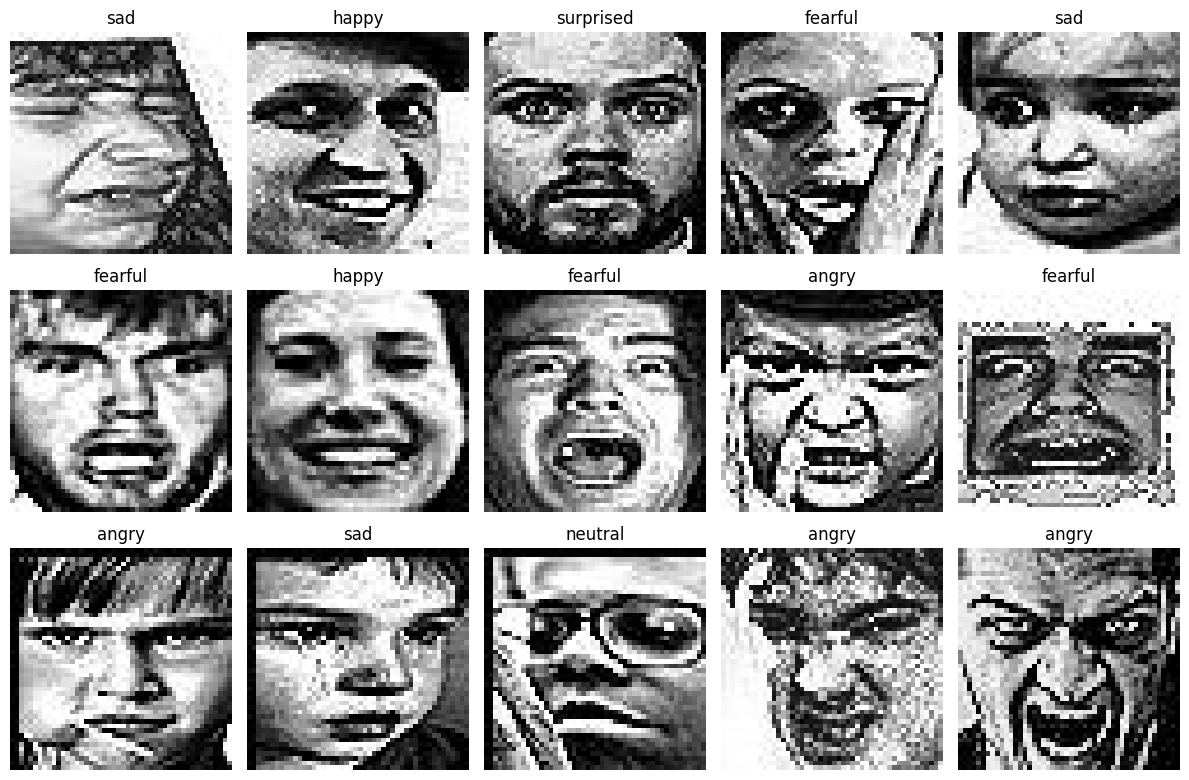

In [188]:
def visualize_data(images, labels, rows=3, cols=5):
    plt.figure(figsize=(12, 8))

    random_indexes = np.random.randint(0, len(images), rows * cols)

    for n, i in enumerate(random_indexes):
        plt.subplot(rows, cols, n + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(labels[i])

    plt.tight_layout()
    plt.show()


visualize_data(x_train, y_train)


## 8. Check Class Imbalance

Training class distribution:
angry: 4600
fearful: 4600
happy: 4772
neutral: 4600
sad: 4600
surprised: 4600


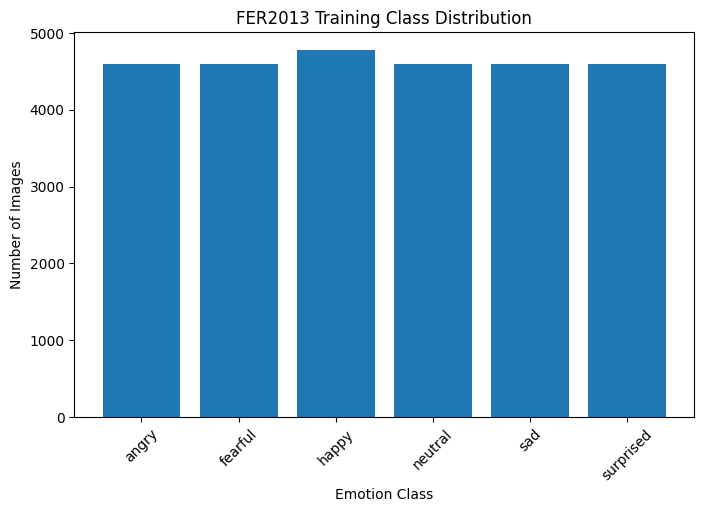

In [189]:
class_counts = Counter(y_train)

print("Training class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("FER2013 Training Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


## 9. Label Encoding

The labels are text, like `happy`, `sad`, and `angry`.

The CNN needs numerical labels, so we convert them to numbers, then to one-hot vectors.


In [190]:
label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

y_train_encoded = to_categorical(y_train_int, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_int, num_classes=num_classes)

x_train_split, x_val, y_train_split_encoded, y_val_encoded, y_train_split_int, y_val_int = train_test_split(
    x_train,
    y_train_encoded,
    y_train_int,
    test_size=0.2,
    random_state=42,
    stratify=y_train_int
)

print("y_train_encoded:", y_train_encoded.shape)
print("y_test_encoded:", y_test_encoded.shape)
print("x_train_split:", x_train_split.shape)
print("x_val:", x_val.shape)
print("Training split class distribution:")
for class_index, count in sorted(Counter(y_train_split_int).items()):
    print(f"{class_names[class_index]}: {count}")
print("Validation split class distribution:")
for class_index, count in sorted(Counter(y_val_int).items()):
    print(f"{class_names[class_index]}: {count}")


Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 6
y_train_encoded: (27772, 6)
y_test_encoded: (2908, 6)
x_train_split: (22217, 48, 48, 1)
x_val: (5555, 48, 48, 1)
Training split class distribution:
angry: 3680
fearful: 3680
happy: 3817
neutral: 3680
sad: 3680
surprised: 3680
Validation split class distribution:
angry: 920
fearful: 920
happy: 955
neutral: 920
sad: 920
surprised: 920


## 10. Class Weighting

**Purpose:** Solve class imbalance during training.

Minority classes, such as `disgusted`, get higher weight, so the model does not ignore them.


In [191]:
balanced_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_split_int),
    y=y_train_split_int
)

balanced_class_weights = dict(enumerate(balanced_class_weight_values))
soft_class_weights = {
    class_index: min(float(np.sqrt(weight)), 3.0)
    for class_index, weight in balanced_class_weights.items()
}

class_weights = soft_class_weights if USE_SOFT_CLASS_WEIGHTS else balanced_class_weights
fit_class_weights = class_weights if USE_CLASS_WEIGHTS else None

print("Balanced class weights:")
for class_index, weight in balanced_class_weights.items():
    print(f"{class_names[class_index]}: {weight:.4f}")

print()
print("Soft/capped class weights used if USE_CLASS_WEIGHTS=True:")
for class_index, weight in soft_class_weights.items():
    print(f"{class_names[class_index]}: {weight:.4f}")

print()
print("Class weights enabled:", USE_CLASS_WEIGHTS)


Balanced class weights:
angry: 1.0062
fearful: 1.0062
happy: 0.9701
neutral: 1.0062
sad: 1.0062
surprised: 1.0062

Soft/capped class weights used if USE_CLASS_WEIGHTS=True:
angry: 1.0031
fearful: 1.0031
happy: 0.9849
neutral: 1.0031
sad: 1.0031
surprised: 1.0031

Class weights enabled: False


## 11. Data AugmentationXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

**Purpose:** Make the training data more varied.

We apply augmentation only to the training data, not the test data.

Techniques used:
- Rotation
- Width shift
- Height shift
- Zoom
- Horizontal flip
- Brightness variation


In [192]:
# No ImageDataGenerator here.
# We use the already-saved train_new images directly.

validation_data = (x_val, y_val_encoded)

print("Training data used directly:", x_train_split.shape, y_train_split_encoded.shape)
print("Validation data:", x_val.shape, y_val_encoded.shape)


Training data used directly: (22217, 48, 48, 1) (22217, 6)
Validation data: (5555, 48, 48, 1) (5555, 6)


## 12. Show Augmented ImagesXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

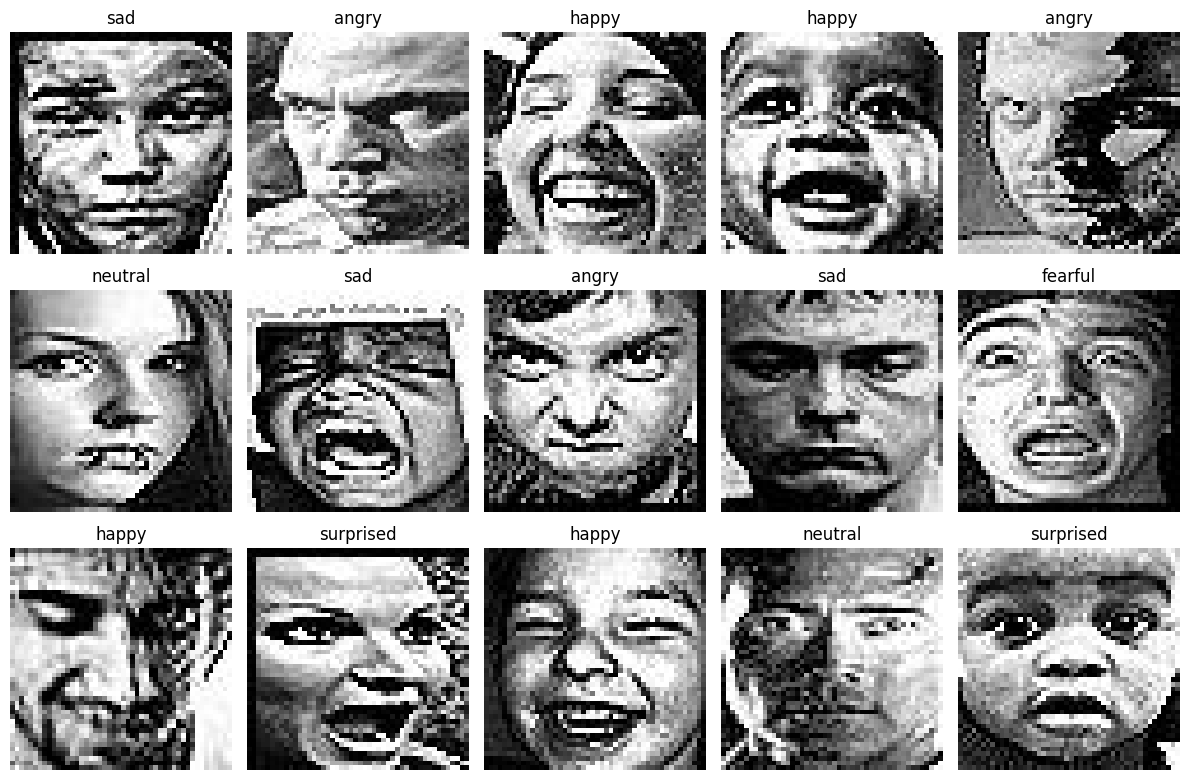

In [193]:
plt.figure(figsize=(12, 8))
random_indexes = np.random.randint(0, len(x_train_split), 15)

for plot_i, data_i in enumerate(random_indexes):
    plt.subplot(3, 5, plot_i + 1)
    plt.imshow(x_train_split[data_i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(class_names[np.argmax(y_train_split_encoded[data_i])])

plt.tight_layout()
plt.show()


## 13. Build Custom CNN From Scratch

This is the Lab9-style CNN model, adjusted for FER2013 emotion recognition.


In [194]:
def create_custom_cnn(image_size, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=image_size),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Flatten(),

        layers.Dense(256,activation="relu",kernel_initializer="he_normal",kernel_regularizer=l2(0.001)),###

        layers.Dropout(0.50),
        layers.Dense(num_classes, activation="softmax")


    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


single_model = create_custom_cnn(image_size, num_classes)


Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_72 (Conv2D)          (None, 48, 48, 32)        320       
                                                                 
 conv2d_73 (Conv2D)          (None, 48, 48, 32)        9248      
                                                                 
 max_pooling2d_36 (MaxPoolin  (None, 24, 24, 32)       0         
 g2D)                                                            
                                                                 
 dropout_48 (Dropout)        (None, 24, 24, 32)        0         
                                                                 
 conv2d_74 (Conv2D)          (None, 24, 24, 64)        18496     
                                                                 
 conv2d_75 (Conv2D)          (None, 24, 24, 64)        36928     
                                                     

In [195]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_fer2013_cnn_model_train_new.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = single_model.fit(
    x_train_split,
    y_train_split_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=validation_data,
    class_weight=fit_class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)







# =========================
# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import tensorflow as tf

# =========================
# Evaluation Metrics
# =========================

best_model_path = "best_fer2013_cnn_model_train_new.h5"

if os.path.exists(best_model_path):
    print("Loading best checkpoint:", best_model_path)
    evaluation_model = tf.keras.models.load_model(best_model_path)
else:
    print("Best checkpoint not found; using current model.")
    evaluation_model = single_model

# Predict probabilities
y_pred_prob = evaluation_model.predict(x_test)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test_int

# One-hot true labels for ROC-AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_names))

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

# Main metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true_one_hot,
    y_pred_prob,
    average="weighted",
    multi_class="ovr"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)


Epoch 1/50
344/348 [============================>.] - ETA: 0s - loss: 2.0797 - accuracy: 0.2857
Epoch 1: val_accuracy improved from -inf to 0.53843, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 5s 13ms/step - loss: 2.0759 - accuracy: 0.2872 - val_loss: 1.5463 - val_accuracy: 0.5384 - lr: 5.0000e-04
Epoch 2/50
347/348 [============================>.] - ETA: 0s - loss: 1.4191 - accuracy: 0.5583
Epoch 2: val_accuracy improved from 0.53843 to 0.66481, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 4s 13ms/step - loss: 1.4190 - accuracy: 0.5584 - val_loss: 1.1288 - val_accuracy: 0.6648 - lr: 5.0000e-04
Epoch 3/50
345/348 [============================>.] - ETA: 0s - loss: 1.1379 - accuracy: 0.6514
Epoch 3: val_accuracy improved from 0.66481 to 0.71161, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 5s 13ms/step - loss: 1.1366 - accuracy: 0.6520 - v

In [196]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import tensorflow as tf

# =========================
# Evaluation Metrics
# =========================

best_model_path = "best_fer2013_cnn_model_train_new.h5"

if os.path.exists(best_model_path):
    print("Loading best checkpoint:", best_model_path)
    evaluation_model = tf.keras.models.load_model(best_model_path)
else:
    print("Best checkpoint not found; using current model.")
    evaluation_model = single_model

# Predict probabilities
y_pred_prob = evaluation_model.predict(x_test)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test_int

# One-hot true labels for ROC-AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_names))

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

# Main metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true_one_hot,
    y_pred_prob,
    average="weighted",
    multi_class="ovr"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)

Loading best checkpoint: best_fer2013_cnn_model_train_new.h5
91/91 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

       angry       0.70      0.79      0.74       162
     fearful       0.71      0.55      0.62        74
       happy       0.93      0.90      0.91      1185
     neutral       0.75      0.82      0.78       680
         sad       0.77      0.71      0.74       478
   surprised       0.78      0.81      0.80       329

    accuracy                           0.82      2908
   macro avg       0.77      0.76      0.77      2908
weighted avg       0.83      0.82      0.82      2908

Accuracy: 0.8242778541953233
Precision: 0.827093486964722
Recall: 0.8242778541953233
F1-Score: 0.8245910931689838
ROC-AUC: 0.968214692139585


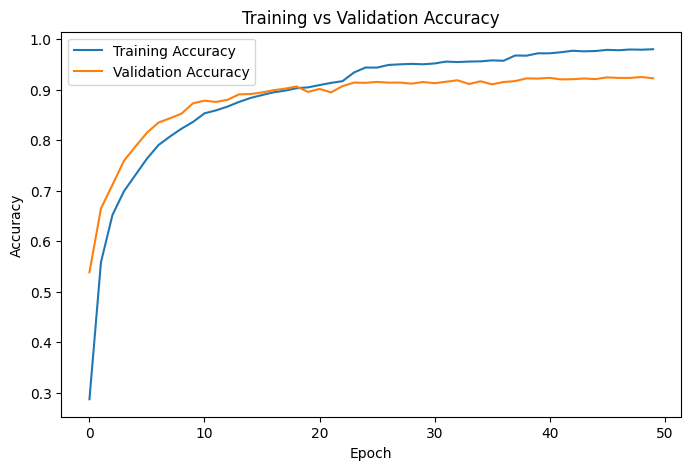

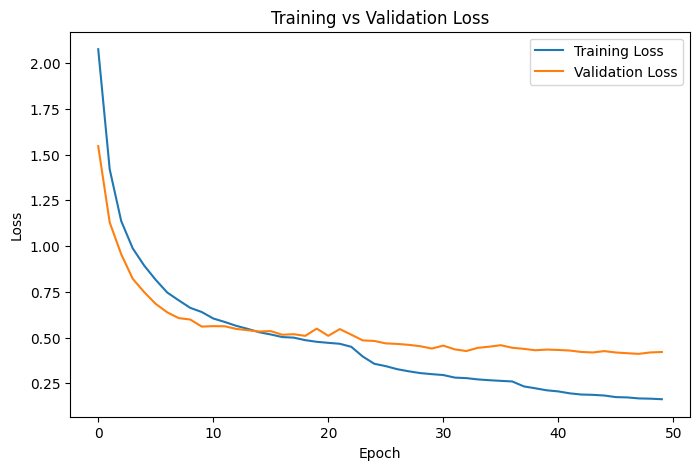

In [197]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [198]:
best_model_path = "best_fer2013_cnn_model_train_new.h5"
if os.path.exists(best_model_path):
    print("Loading best checkpoint:", best_model_path)
    evaluation_model = tf.keras.models.load_model(best_model_path)
else:
    print("Best checkpoint not found; using current in-memory model.")
    evaluation_model = single_model

predictions = evaluation_model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test_int

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print()
print("Predicted class distribution:")
for class_index, count in sorted(Counter(y_pred).items()):
    print(f"{class_names[class_index]}: {count}")


Loading best checkpoint: best_fer2013_cnn_model_train_new.h5
91/91 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

       angry       0.70      0.79      0.74       162
     fearful       0.71      0.55      0.62        74
       happy       0.93      0.90      0.91      1185
     neutral       0.75      0.82      0.78       680
         sad       0.77      0.71      0.74       478
   surprised       0.78      0.81      0.80       329

    accuracy                           0.82      2908
   macro avg       0.77      0.76      0.77      2908
weighted avg       0.83      0.82      0.82      2908

Accuracy: 0.8242778541953233
Precision: 0.827093486964722
Recall: 0.8242778541953233
F1-Score: 0.8245910931689838

Predicted class distribution:
angry: 182
fearful: 58
happy: 1143
neutral: 742
sad: 440
surprised: 343


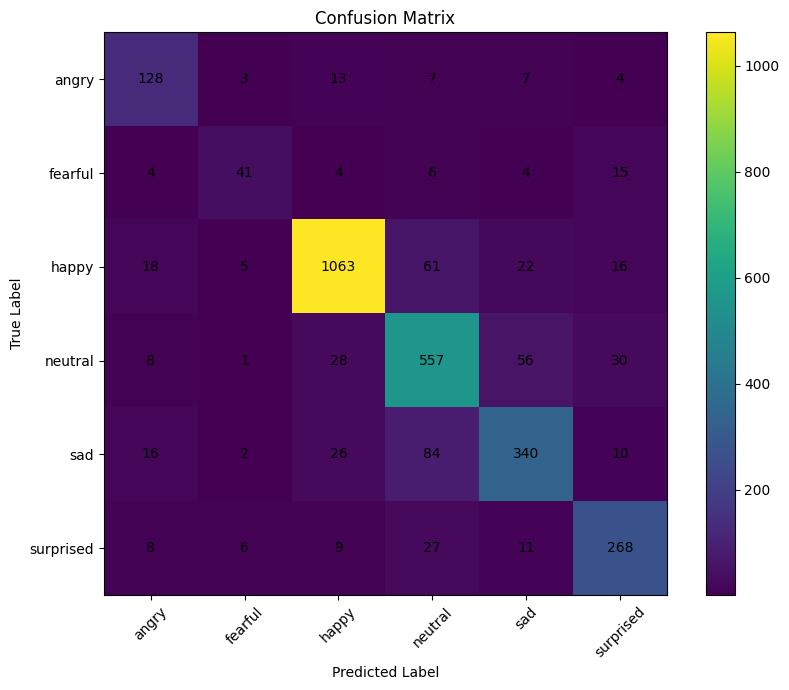

In [199]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [200]:
x_train_rgb = np.repeat(x_train, 3, axis=-1)
x_test_rgb = np.repeat(x_test, 3, axis=-1)

transfer_image_size = (height, width, 3)

print("x_train_rgb:", x_train_rgb.shape)
print("x_test_rgb:", x_test_rgb.shape)


x_train_rgb: (27772, 48, 48, 3)
x_test_rgb: (2908, 48, 48, 3)


In [201]:
def create_mobilev3small(image_size, num_classes):
    base_model = tf.keras.applications.MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=image_size
    )

    # Freeze most layers first
    for layer in base_model.layers:
        layer.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


# If you want to train MobileNet later, create RGB splits first and train directly:
# x_train_split_rgb = np.repeat(x_train_split, 3, axis=-1)
# x_val_rgb = np.repeat(x_val, 3, axis=-1)
# mobile_model = create_mobilev3small((height, width, 3), num_classes)
# mobile_history = mobile_model.fit(
#     x_train_split_rgb,
#     y_train_split_encoded,
#     batch_size=batch_size,
#     epochs=epochs,
#     validation_data=(x_val_rgb, y_val_encoded),
#     class_weight=fit_class_weights,
#     callbacks=[early_stop]
# )
